# imports

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [9]:
df = pd.read_csv("merged_df.csv")
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').set_index('time')


# features and scale

In [10]:
target = "total load actual"

# features = everything except target and its forecast
features = df.drop(columns=["total load actual", "total load forecast"]).columns.tolist()

# Build clean dataset
data = df[features + [target]].dropna().reset_index(drop=True)


In [11]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(data[features])
y_scaled = scaler_y.fit_transform(data[[target]])


In [13]:
def create_sequences(X, y, lookback=24):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

lookback = 24
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)

print("X_seq:", X_seq.shape)   # (samples, 24, num_features)
print("y_seq:", y_seq.shape)   # (samples, 1)


X_seq: (35040, 24, 24)
y_seq: (35040, 1)


# train/test split

In [14]:
train_size = int(0.8 * len(X_seq))

X_train = X_seq[:train_size]
X_test  = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test  = y_seq[train_size:]


# GRU

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model_gru = Sequential([
    GRU(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        17,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,393 (75.75 KB)

 Trainable params: 19,393 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0237 - val_loss: 0.0055
Epoch 2/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0037 - val_loss: 0.0045
Epoch 3/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0032 - val_loss: 0.0044
Epoch 4/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0029 - val_loss: 0.0043
Epoch 5/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0026 - val_loss: 0.0039
Epoch 6/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0024 - val_loss: 0.0039
Epoch 7/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0023 - val_loss: 0.0042
Epoch 8/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0022 - val_loss: 0.0037
Epoch 9/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0021 - val_loss: 0.0039
Epoch 10/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 11/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0019 - val_loss: 0.0036
Epoch 12/20
789/789 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

In [17]:
y_pred_scaled = model_gru.predict(X_test)

# inverse-transform
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [18]:
mae  = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100
r2   = r2_score(y_test_inv, y_pred_inv)

print("\n📊 GRU Performance (All Features):")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.3f}")



📊 GRU Performance (All Features):
MAE : 1130.62
RMSE: 1430.43
MAPE: 3.97%
R²  : 0.900


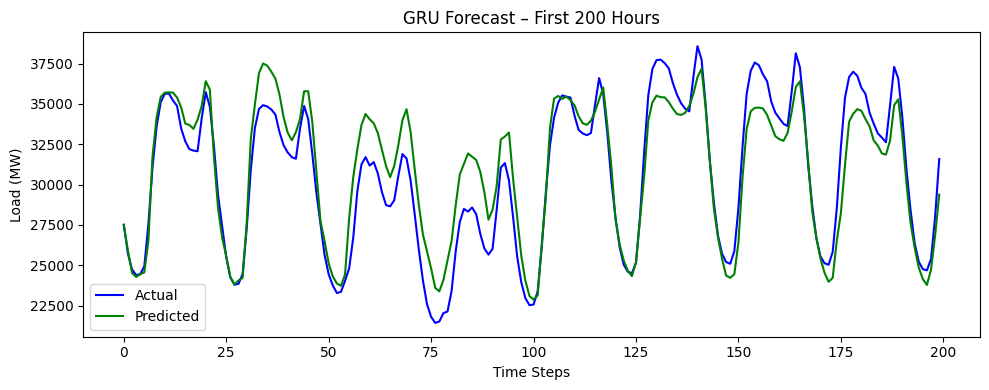

In [20]:
plt.figure(figsize=(10,4))
plt.plot(y_test_inv[:200], label='Actual', color='blue')
plt.plot(y_pred_inv[:200], label='Predicted', color='green')
plt.title("GRU Forecast – First 200 Hours")
plt.xlabel("Time Steps")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


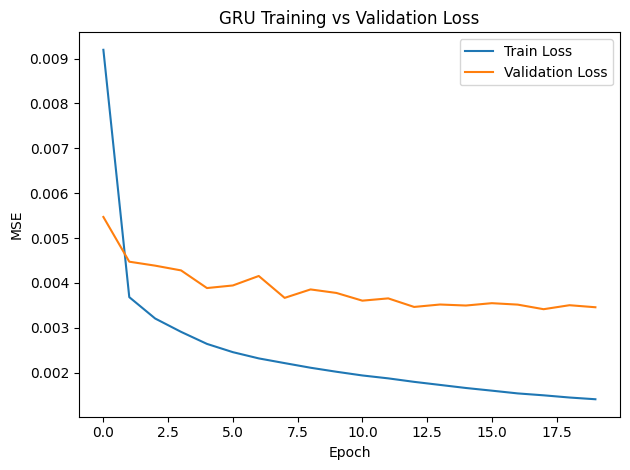

In [22]:

plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()
